<a href="https://colab.research.google.com/github/Duchuy-05/SamSung_Inovation_Campus_2026/blob/master/2026-08-13-chapter4-exerices03_06-covariance-correlation-statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Coding Exercise #0203

### 1. Descriptive statistics:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/My Drive/Slides/Examples/Chapter 4/data_studentlist.csv', header='infer')


In [5]:
df.head()

,name,gender,age,grade,absence,bloodtype,height,weight
0,Jared Diamond,M,23,3,Y,O,165.3,68.2
1,Sarah O'Donnel,F,22,2,N,AB,170.1,53.0
2,Brian Martin,M,24,4,N,B,175.0,80.1
3,David Hassel,M,23,3,N,AB,182.1,85.7
4,Clara Rodriquez,F,20,1,Y,A,168.0,49.5


In [6]:
df.shape

(17, 8)

#### 1.1. Sample statistics:

In [7]:
df['height'].mean()

np.float64(170.03529411764703)

In [10]:
# Unbiased estimator of the variance.
df['height'].var(ddof=1)

61.61867647058828

In [11]:
# Unbiased estimator of the standard deviation.
df['height'].std(ddof=1)

7.849756459316956

In [12]:
# Median.
df['height'].median()

169.2

In [21]:
df['height'].max()

182.1

In [14]:
df['height'].min()

155.2

In [13]:
# Quantile at alpha = 0.1
df['height'].quantile(0.1)

np.float64(160.48)

In [17]:
# Quantile at alpha = 0.9
df['height'].quantile(0.9)

np.float64(179.1)

#### 1.2. Boxplot:

In [18]:
# The Inter Quartile Range
IQR = df['height'].quantile(0.75) - df['height'].quantile(0.25)
IQR

np.float64(10.799999999999983)

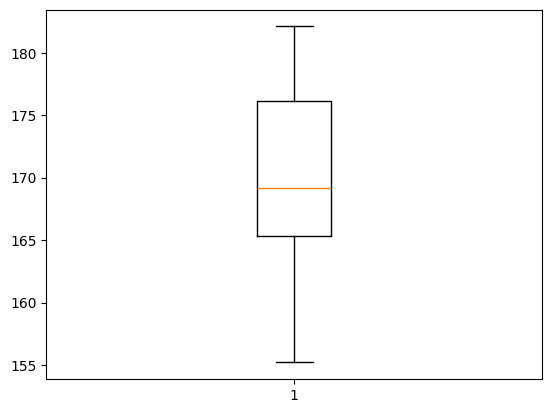

In [19]:
# Show a Boxplot for the height.
plt.boxplot(df['height'])
plt.show()

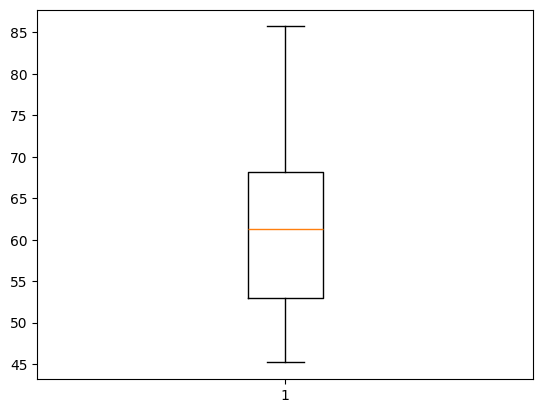

In [20]:
# Show a Boxplot for the weight.
plt.boxplot(df['weight'])
plt.show()

#### 1.3. Covariance and Correlation: hiệp phương sai và tương quan

In [24]:
# Covariance
df['height'].cov(df['weight'])

np.float64(61.790698529411785)

In [25]:
# Correlation
df['height'].corr(df['weight'])

np.float64(0.6641815979588611)

In [28]:
# Calculate the correlation using the covariance
df['height'].cov(df['weight']) / (df['height'].std(ddof=1) * df['weight'].std(ddof=1))

np.float64(0.6641815979588611)

#### 1.4. Visualization:

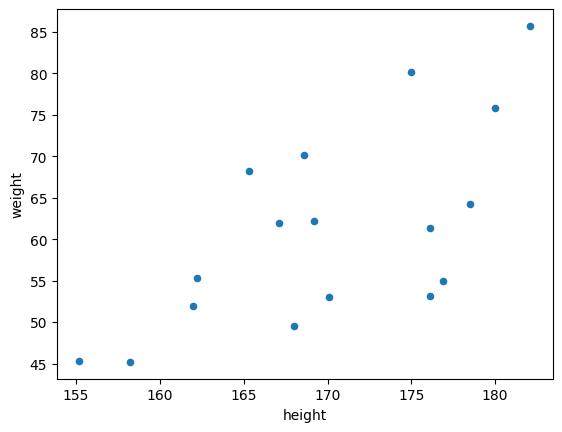

In [29]:
df.plot.scatter(x='height', y='weight')
plt.show()

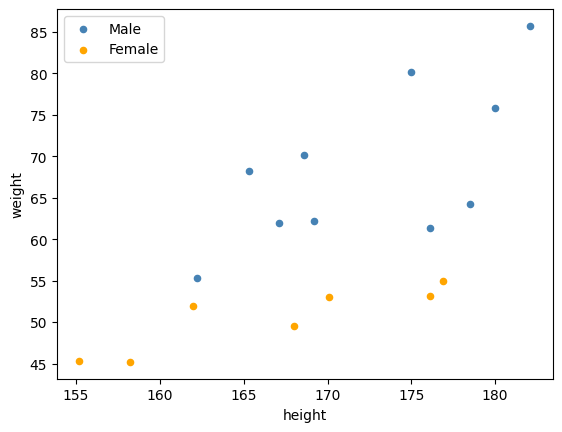

In [33]:
base = df[df.gender=='M'].plot.scatter(x='height', y='weight', color='steelblue', label='Male')
df[df.gender=='F'].plot.scatter(x='height', y='weight', color='orange', label='Female', ax=base)
plt.show()

## Coding Exercise #0206

### 1. Interval Estimation of the Proportion:

In [34]:
import numpy as np
import scipy.stats as st

1). Có hai ứng cử viên trong cuộc bầu cử: A và B. Ứng cử viên A muốn khảo sát tỷ lệ ủng hộ dành cho mình. Trong số 100 người được khảo sát, có 55 người phản hồi tích cực. Liệu A có thể chắc chắn về kết quả cuộc bầu cử này không?

Giả định rằng A sẽ đắc cử nếu đạt được từ 50% số phiếu trở lên.
Sử dụng khoảng tin cậy 95%.

In [35]:
n_yes = 55
n_total = 100
p_mean = n_yes/n_total
SE = np.sqrt(p_mean*(1-p_mean)/n_total)
st.norm.interval(0.95, loc=p_mean, scale=SE)

(np.float64(0.45249302291006066), np.float64(0.6475069770899394))

=> Khoảng tin cậy có giới hạn dưới thấp hơn 50%. Do đó, không thể khẳng định điều này với mức tin cậy 95%.

2). Trong số 1.000 người được khảo sát, có 550 người đưa ra phản hồi tích cực. Liệu A có thể chắc chắn về kết quả cuộc bầu cử này không?

Giả định rằng A đắc cử nếu đạt tỷ lệ ủng hộ từ 50% trở lên.
Sử dụng khoảng tin cậy 95%.

In [36]:
n_yes = 550
n_total = 1000
p_mean = n_yes/n_total
SE = np.sqrt(p_mean*(1-p_mean)/n_total)
st.norm.interval(0.95, loc=p_mean, scale=SE)

(np.float64(0.5191655864637935), np.float64(0.5808344135362066))

=> Khoảng tin cậy có giới hạn dưới nằm trên mức 50%. Do đó, A có thể chắc chắn với mức tin cậy 95%.